<a href="https://colab.research.google.com/github/Renusridarla/customer-churn-prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
# Cell 2: Create Customer Churn Dataset

np.random.seed(42)

n = 1200

data = {
    "CustomerID": [f"CUST{i+10001}" for i in range(n)],
    "Gender": np.random.choice(["Female", "Male"], n),
    "SeniorCitizen": np.random.choice([0, 1], n, p=[0.84, 0.16]),
    "Partner": np.random.choice(["Yes", "No"], n),
    "Dependents": np.random.choice(["Yes", "No"], n),
    "Tenure": np.random.randint(1, 73, n),
    "PhoneService": np.random.choice(["Yes", "No"], n, p=[0.90, 0.10]),
    "InternetService": np.random.choice(
        ["DSL", "Fiber optic", "No"],
        n,
        p=[0.35, 0.45, 0.20]
    ),
    "Contract": np.random.choice(
        ["Month-to-month", "One year", "Two year"],
        n,
        p=[0.55, 0.22, 0.23]
    ),
    "PaymentMethod": np.random.choice(
        ["Electronic check", "Mailed check",
         "Bank transfer", "Credit card"],
        n
    ),
    "MonthlyCharges": np.round(
        np.random.uniform(20, 120, n), 2
    )
}

df = pd.DataFrame(data)

# Generate Total Charges
df["TotalCharges"] = np.round(
    df["MonthlyCharges"] * df["Tenure"] +
    np.random.normal(0, 50, n),
    2
)

# Generate churn based on customer characteristics
churn_probability = (
    0.10
    + 0.20 * (df["Contract"] == "Month-to-month")
    + 0.12 * (df["InternetService"] == "Fiber optic")
    + 0.10 * (df["PaymentMethod"] == "Electronic check")
    + 0.10 * (df["Tenure"] <= 12)
    + 0.08 * (df["MonthlyCharges"] > 80)
    + 0.05 * (df["SeniorCitizen"] == 1)
)

churn_probability = np.clip(churn_probability, 0, 0.85)

df["Churn"] = np.where(
    np.random.random(n) < churn_probability,
    "Yes",
    "No"
)

# Add a few missing values for preprocessing practice
missing_columns = ["MonthlyCharges", "TotalCharges", "InternetService"]

for column in missing_columns:
    indices = np.random.choice(df.index, 5, replace=False)
    df.loc[indices, column] = np.nan

# Add a few duplicate records
df = pd.concat(
    [df, df.iloc[[10, 25]]],
    ignore_index=True
)

print("Dataset created successfully!")
print("Dataset shape:", df.shape)

df.head()


Dataset created successfully!
Dataset shape: (1202, 13)


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST10001,Female,0,Yes,Yes,57,Yes,No,Month-to-month,Mailed check,68.01,3916.26,No
1,CUST10002,Male,0,No,Yes,72,No,Fiber optic,Two year,Credit card,101.57,7287.29,Yes
2,CUST10003,Female,0,Yes,Yes,7,Yes,Fiber optic,One year,Electronic check,26.27,241.10,No
3,CUST10004,Female,0,No,Yes,56,Yes,DSL,Month-to-month,Bank transfer,101.55,5640.25,Yes
4,CUST10005,Female,0,No,No,67,Yes,Fiber optic,Month-to-month,Electronic check,69.48,4697.83,No


In [3]:
# Cell 3: Inspect and Understand the Dataset

print("===== DATASET INFORMATION =====")
print()

print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 records:")
display(df.head())

print("\nLast 5 records:")
display(df.tail())

print("\nStatistical Summary:")
display(df.describe(include="all"))

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

===== DATASET INFORMATION =====

Number of rows and columns:
(1202, 13)

Column names:
['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'PhoneService', 'InternetService', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
CustomerID          object
Gender              object
SeniorCitizen        int64
Partner             object
Dependents          object
Tenure               int64
PhoneService        object
InternetService     object
Contract            object
PaymentMethod       object
MonthlyCharges     float64
TotalCharges       float64
Churn               object
dtype: object

First 5 records:


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST10001,Female,0,Yes,Yes,57,Yes,No,Month-to-month,Mailed check,68.01,3916.26,No
1,CUST10002,Male,0,No,Yes,72,No,Fiber optic,Two year,Credit card,101.57,7287.29,Yes
2,CUST10003,Female,0,Yes,Yes,7,Yes,Fiber optic,One year,Electronic check,26.27,241.10,No
3,CUST10004,Female,0,No,Yes,56,Yes,DSL,Month-to-month,Bank transfer,101.55,5640.25,Yes
4,CUST10005,Female,0,No,No,67,Yes,Fiber optic,Month-to-month,Electronic check,69.48,4697.83,No



Last 5 records:


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1197,CUST11198,Female,0,No,No,19,Yes,Fiber optic,One year,Bank transfer,45.87,898.86,No
1198,CUST11199,Female,0,No,No,26,Yes,No,Month-to-month,Credit card,91.56,2462.00,No
1199,CUST11200,Female,0,Yes,No,40,Yes,Fiber optic,One year,Credit card,92.16,3643.61,No
1200,CUST10011,Female,0,Yes,Yes,5,Yes,Fiber optic,Month-to-month,Credit card,34.11,225.69,No
1201,CUST10026,Male,0,No,No,66,Yes,DSL,Month-to-month,Bank transfer,29.33,1896.29,Yes



Statistical Summary:


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,1202,1202,1202.000000,1202,1202,1202.000000,1202,1197,1202,1202,1197.000000,1197.000000,1202
unique,1200,2,NaN,2,2,NaN,2,3,3,4,NaN,NaN,2
top,CUST10011,Female,NaN,No,Yes,NaN,Yes,Fiber optic,Month-to-month,Bank transfer,NaN,NaN,No
freq,2,602,NaN,613,623,NaN,1098,523,644,322,NaN,NaN,786
mean,NaN,NaN,0.158070,NaN,NaN,37.039933,NaN,NaN,NaN,NaN,70.053534,2607.405163,NaN
std,NaN,NaN,0.364958,NaN,NaN,20.759679,NaN,NaN,NaN,NaN,28.773683,1934.767611,NaN
min,NaN,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,20.140000,-8.320000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,19.000000,NaN,NaN,NaN,NaN,45.860000,1061.070000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,37.500000,NaN,NaN,NaN,NaN,70.920000,2138.760000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,56.000000,NaN,NaN,NaN,NaN,95.580000,3809.160000,NaN



Missing Values:
CustomerID         0
Gender             0
SeniorCitizen      0
Partner            0
Dependents         0
Tenure             0
PhoneService       0
InternetService    5
Contract           0
PaymentMethod      0
MonthlyCharges     5
TotalCharges       5
Churn              0
dtype: int64

Duplicate Records:
2

Churn Distribution:
Churn
No     786
Yes    416
Name: count, dtype: int64

Churn Percentage:
Churn
No     65.391015
Yes    34.608985
Name: proportion, dtype: float64


In [4]:
# Cell 4: Data Cleaning and Preprocessing

print("===== DATA CLEANING AND PREPROCESSING =====\n")

# Create a copy of the original dataset
cleaned_df = df.copy()

# 1. Remove duplicate records
duplicates_before = cleaned_df.duplicated().sum()

cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)

print("Duplicate records removed:", duplicates_before)

# 2. Convert TotalCharges to numeric
cleaned_df["TotalCharges"] = pd.to_numeric(
    cleaned_df["TotalCharges"],
    errors="coerce"
)

# 3. Check missing values before handling
print("\nMissing values before handling:")
print(cleaned_df.isnull().sum())

# 4. Handle missing numerical values using median
numerical_columns = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for column in numerical_columns:
    cleaned_df[column] = cleaned_df[column].fillna(
        cleaned_df[column].median()
    )

# 5. Handle missing categorical values using mode
categorical_columns = [
    "Gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "InternetService",
    "Contract",
    "PaymentMethod"
]

for column in categorical_columns:
    cleaned_df[column] = cleaned_df[column].fillna(
        cleaned_df[column].mode()[0]
    )

# 6. Check missing values after handling
print("\nMissing values after handling:")
print(cleaned_df.isnull().sum())

# 7. Display cleaned dataset information
print("\nCleaned dataset shape:")
print(cleaned_df.shape)

print("\nCleaned dataset:")
display(cleaned_df.head())

# 8. Basic statistical summary
print("\nStatistical summary after cleaning:")
display(cleaned_df.describe())


===== DATA CLEANING AND PREPROCESSING =====

Duplicate records removed: 2

Missing values before handling:
CustomerID         0
Gender             0
SeniorCitizen      0
Partner            0
Dependents         0
Tenure             0
PhoneService       0
InternetService    5
Contract           0
PaymentMethod      0
MonthlyCharges     5
TotalCharges       5
Churn              0
dtype: int64

Missing values after handling:
CustomerID         0
Gender             0
SeniorCitizen      0
Partner            0
Dependents         0
Tenure             0
PhoneService       0
InternetService    0
Contract           0
PaymentMethod      0
MonthlyCharges     0
TotalCharges       0
Churn              0
dtype: int64

Cleaned dataset shape:
(1200, 13)

Cleaned dataset:


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST10001,Female,0,Yes,Yes,57,Yes,No,Month-to-month,Mailed check,68.01,3916.26,No
1,CUST10002,Male,0,No,Yes,72,No,Fiber optic,Two year,Credit card,101.57,7287.29,Yes
2,CUST10003,Female,0,Yes,Yes,7,Yes,Fiber optic,One year,Electronic check,26.27,241.10,No
3,CUST10004,Female,0,No,Yes,56,Yes,DSL,Month-to-month,Bank transfer,101.55,5640.25,Yes
4,CUST10005,Female,0,No,No,67,Yes,Fiber optic,Month-to-month,Electronic check,69.48,4697.83,No



Statistical summary after cleaning:


,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,0.158333,37.042500,70.121450,2608.045333
std,0.365205,20.739515,28.694806,1931.245127
min,0.000000,1.000000,20.140000,-8.320000
25%,0.000000,19.000000,45.997500,1066.877500
50%,0.000000,37.500000,71.020000,2142.480000
75%,0.000000,56.000000,95.355000,3800.452500
max,1.000000,72.000000,119.970000,8385.010000


===== EXPLORATORY DATA ANALYSIS =====

Dataset shape: (1200, 13)

Numerical columns:
['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['CustomerID', 'Gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'Contract', 'PaymentMethod', 'Churn']

===== SUMMARY STATISTICS =====


,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,0.158333,37.042500,70.121450,2608.045333
std,0.365205,20.739515,28.694806,1931.245127
min,0.000000,1.000000,20.140000,-8.320000
25%,0.000000,19.000000,45.997500,1066.877500
50%,0.000000,37.500000,71.020000,2142.480000
75%,0.000000,56.000000,95.355000,3800.452500
max,1.000000,72.000000,119.970000,8385.010000



===== CHURN DISTRIBUTION =====
Churn
No     785
Yes    415
Name: count, dtype: int64

===== CHURN PERCENTAGE =====
Churn
No     65.416667
Yes    34.583333
Name: proportion, dtype: float64


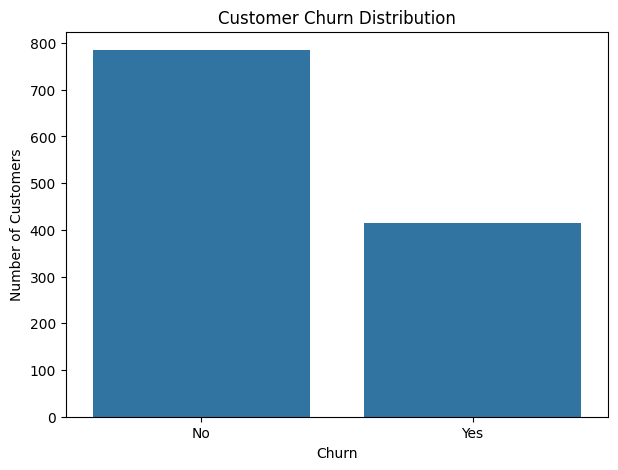

In [5]:
# Cell 5: Exploratory Data Analysis (EDA)

print("===== EXPLORATORY DATA ANALYSIS =====\n")

# Basic information
print("Dataset shape:", cleaned_df.shape)

print("\nNumerical columns:")
print(cleaned_df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(cleaned_df.select_dtypes(include="object").columns.tolist())

# Summary statistics
print("\n===== SUMMARY STATISTICS =====")
display(cleaned_df.describe())

# Churn count
print("\n===== CHURN DISTRIBUTION =====")
print(cleaned_df["Churn"].value_counts())

print("\n===== CHURN PERCENTAGE =====")
churn_percentage = cleaned_df["Churn"].value_counts(normalize=True) * 100
print(churn_percentage)
# Churn Distribution Visualization

plt.figure(figsize=(7, 5))

sns.countplot(
    data=cleaned_df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()


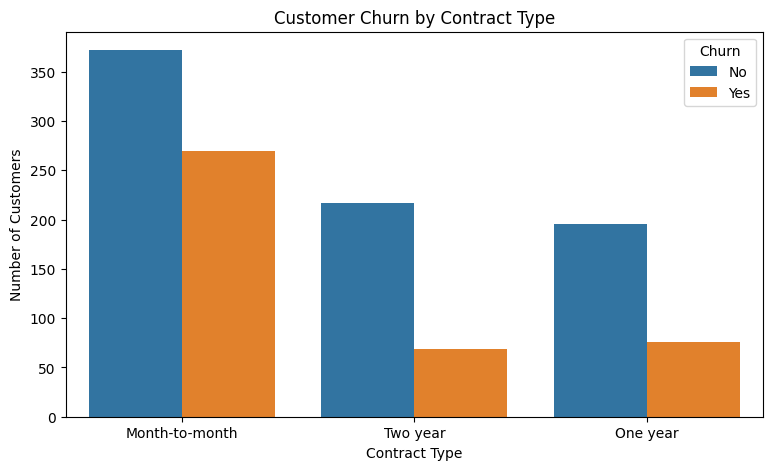

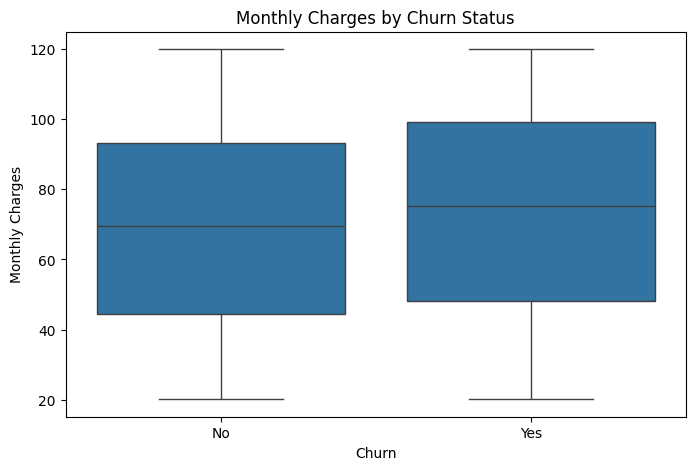

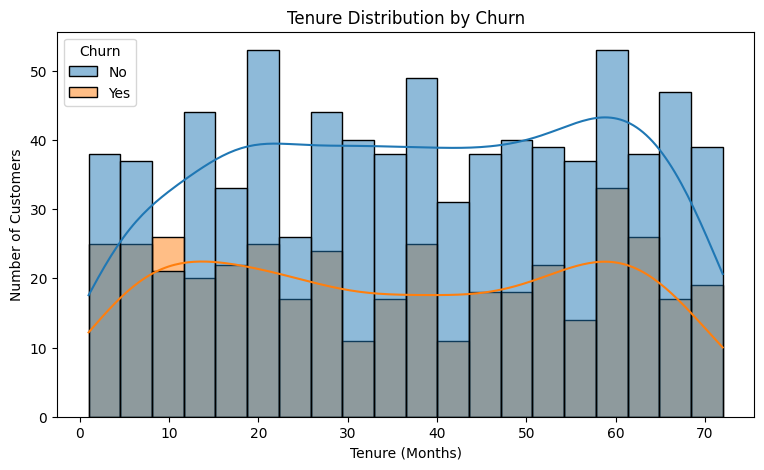

In [6]:
# Churn by Contract Type

plt.figure(figsize=(9, 5))

sns.countplot(
    data=cleaned_df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()
# Monthly Charges vs Churn

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=cleaned_df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()
# Tenure Distribution by Churn

plt.figure(figsize=(9, 5))

sns.histplot(
    data=cleaned_df,
    x="Tenure",
    hue="Churn",
    bins=20,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

===== CORRELATION ANALYSIS =====

Correlation Matrix:


,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.025428,0.014811,0.056810
Tenure,0.025428,1.000000,0.028899,0.762870
MonthlyCharges,0.014811,0.028899,1.000000,0.583026
TotalCharges,0.056810,0.762870,0.583026,1.000000


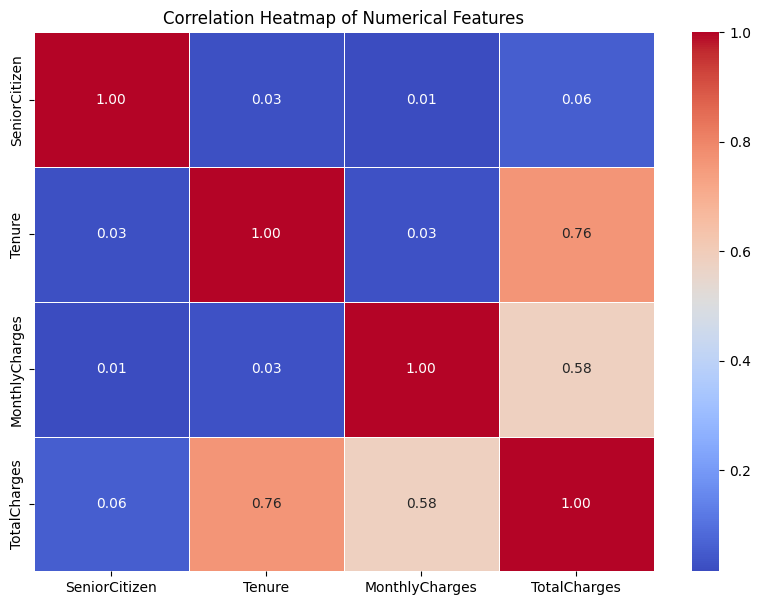


===== OUTLIER ANALYSIS =====


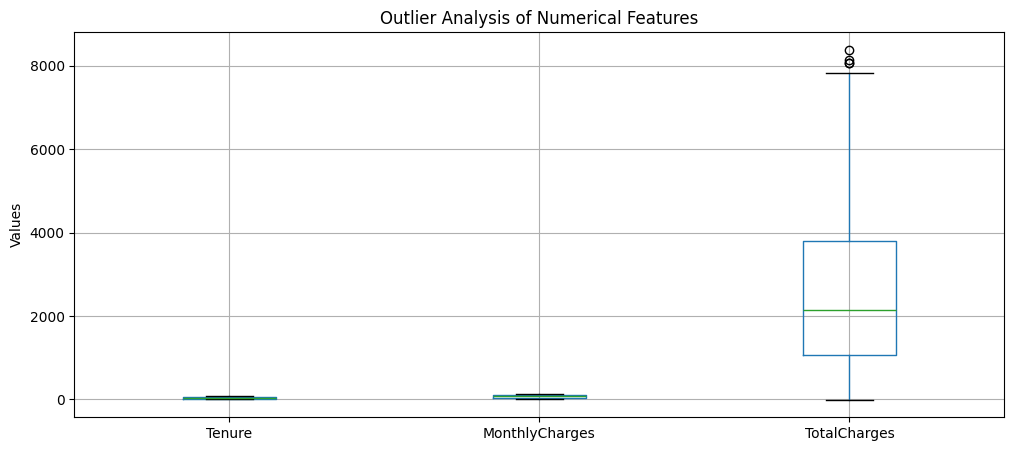


===== OUTLIER COUNTS USING IQR =====
Tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 4 outliers


In [7]:
# Cell 6: Correlation Analysis and Outlier Detection

print("===== CORRELATION ANALYSIS =====")

# Select numerical columns
numerical_data = cleaned_df.select_dtypes(include=np.number)

# Calculate correlation matrix
correlation_matrix = numerical_data.corr()

print("\nCorrelation Matrix:")
display(correlation_matrix)

# -------------------------------
# Correlation Heatmap
# -------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()


# -------------------------------
# Outlier Analysis
# -------------------------------

print("\n===== OUTLIER ANALYSIS =====")

# Numerical columns for box plots
outlier_columns = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges"
]

plt.figure(figsize=(12, 5))

cleaned_df[outlier_columns].boxplot()

plt.title("Outlier Analysis of Numerical Features")
plt.ylabel("Values")
plt.xticks(rotation=0)

plt.show()


# -------------------------------
# IQR-based Outlier Count
# -------------------------------

print("\n===== OUTLIER COUNTS USING IQR =====")

for column in outlier_columns:

    Q1 = cleaned_df[column].quantile(0.25)
    Q3 = cleaned_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = cleaned_df[
        (cleaned_df[column] < lower_bound) |
        (cleaned_df[column] > upper_bound)
    ]

    print(f"{column}: {len(outliers)} outliers")

In [8]:
# Cell 7: Feature Engineering and Encoding

print("===== FEATURE ENGINEERING =====\n")

# Create a copy of the cleaned dataset
model_df = cleaned_df.copy()

# Convert target variable into numerical form
# No = 0, Yes = 1
model_df["Churn"] = model_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Remove CustomerID because it does not contribute
# useful predictive information
model_df = model_df.drop(columns=["CustomerID"])

print("Target variable converted:")
print(model_df["Churn"].value_counts())

print("\nCategorical features:")
categorical_features = model_df.select_dtypes(
    include="object"
).columns.tolist()
print(categorical_features)

print("\nNumerical features:")
numerical_features = model_df.select_dtypes(
    include=np.number
).columns.tolist()

# Remove target from numerical feature list
numerical_features.remove("Churn")

print(numerical_features)

# One-Hot Encoding for categorical variables
encoded_df = pd.get_dummies(
    model_df,
    columns=categorical_features,
    drop_first=True
)

print("\nDataset after encoding:")
print("Rows:", encoded_df.shape[0])
print("Columns:", encoded_df.shape[1])

display(encoded_df.head())

===== FEATURE ENGINEERING =====

Target variable converted:
Churn
0    785
1    415
Name: count, dtype: int64

Categorical features:
['Gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'Contract', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges']

Dataset after encoding:
Rows: 1200
Columns: 16


,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,57,68.01,3916.26,0,False,True,True,True,False,True,False,False,False,False,True
1,0,72,101.57,7287.29,1,True,False,True,False,True,False,False,True,True,False,False
2,0,7,26.27,241.10,0,False,True,True,True,True,False,True,False,False,True,False
3,0,56,101.55,5640.25,1,False,False,True,True,False,False,False,False,False,False,False
4,0,67,69.48,4697.83,0,False,False,False,True,True,False,False,False,False,True,False


In [9]:
# Cell 8: Train-Test Split and Preprocessing Pipeline

print("===== TRAIN-TEST SPLIT & PREPROCESSING =====\n")

# Separate input features (X) and target variable (y)

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Identify numerical and categorical columns
numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data size:", X_train.shape)
print("Testing data size:", X_test.shape)

# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both preprocessing methods
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing pipeline created successfully!")

===== TRAIN-TEST SPLIT & PREPROCESSING =====

Features (X) shape: (1200, 11)
Target (y) shape: (1200,)

Numerical features:
['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['Gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'Contract', 'PaymentMethod']

Training data size: (960, 11)
Testing data size: (240, 11)

Preprocessing pipeline created successfully!


In [10]:
# Cell 9: Train Machine Learning Models

print("===== MACHINE LEARNING MODEL TRAINING =====\n")

# Define the models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=7
    ),

    "Support Vector Machine": SVC(
        probability=True,
        random_state=42
    )
}

# Dictionary to store trained pipelines
trained_models = {}

# Train each model
for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name} trained successfully!")

print("\n===== ALL MODELS TRAINED SUCCESSFULLY =====")

print("\nModels available:")
for name in trained_models:
    print("-", name)


===== MACHINE LEARNING MODEL TRAINING =====

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!
K-Nearest Neighbors trained successfully!
Support Vector Machine trained successfully!

===== ALL MODELS TRAINED SUCCESSFULLY =====

Models available:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Support Vector Machine


In [11]:
# Cell 10: Model Evaluation and Comparison

print("===== MODEL EVALUATION =====\n")

results = []

for name, pipeline in trained_models.items():

    # Make predictions
    y_pred = pipeline.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Create results DataFrame
results_df = pd.DataFrame(results)

# Sort models by F1-score
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("===== MODEL PERFORMANCE =====")

display(
    results_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-Score": "{:.2%}"
    })
)

===== MODEL EVALUATION =====

===== MODEL PERFORMANCE =====


,Model,Accuracy,Precision,Recall,F1-Score
0,K-Nearest Neighbors,58.33%,36.92%,28.92%,32.43%
1,Logistic Regression,63.33%,44.44%,24.10%,31.25%
2,Decision Tree,61.67%,40.82%,24.10%,30.30%
3,Random Forest,63.75%,44.44%,19.28%,26.89%
4,Support Vector Machine,62.92%,36.36%,9.64%,15.24%
